In [ ]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])

# Definir todos los objetos species según el modelo Gri30
species_dict = {S.name: S for S in ct.Species.list_from_file("gri30.yaml")}
# species_dict es un diccionario:
# {objeto1.name: objeto1, objeto2.name: objeto.2}
# keys: las propiedades "name" de los objetos species.
# values: los propios objetos species cuyos atributos (como los coefs para calcular cp)
# se definen en el gri30.yaml.

complete_species = [species_dict[S] for S in ("CH4", "O2", "N2", "CO2", "H2O")]
# complete_species es una lista de objetos species (solo los de en combustión completa)

# Para reacción incompleta añadimos las 53 especies del GRI3.0
incomplete_species = species_dict.values()
# con la función values se crea una lista con los valores del diccionario species_dict,
# es decir, los objetos species.

gas_mix_complete = ct.Solution(thermo="ideal-gas",
                               species=complete_species,
                               transport_model='mixture-averaged',
                               kinetics='gas')
# gas_mix_complete() muestra todos la info sobre el objeto ct.Solution.



gas_mix_incomplete = ct.Solution(thermo="ideal-gas",
                                 species=incomplete_species,
                                 transport_model='mixture-averaged',
                                 kinetics='gas')
# print(f"Transport model: {gas_mix_incomplete.transport_model}")
# de gri30.yaml no he sacado transport_model, por eso no está definido

In [ ]:
#Crear vector con valores de ratio de equivalencia.
phi = np.linspace(0.6, 1.8, 100)

# Inicializar (crear con todo 0) elos vectores.
T_ad_complete = np.zeros(phi.shape)
T_ad_incomplete = np.zeros(phi.shape)
    # ERROR: poner T_ad_incomplete = T_ad_complete.

T_0 = 298 # K
p = ct.one_atm

for i in range(len(phi)):
    #print("%"*80)
    #print(f"Equivalence ratio {phi[i]}")

    # Se restablece T y p iniciales en cada bucle para calcular la T_ad
    # para cada phi cuando se parte de estas cond. iniciales.
    gas_mix_complete.TP = T_0, p
    gas_mix_incomplete.TP = T_0, p

    # El método set_equivalence_ratio de la clase Solution toma
        # · 1 valor phi,
        # · 1 str con nombres de especies y su X en el fuel (si se sabe)
        # · 1 str con nombres de especies y sus X en el oxidizer (si se saben)
    gas_mix_complete.set_equivalence_ratio(phi[i], "CH4", "O2:1, N2:3.76")
        # CH4 no lleva X porque no hay más especies en fuel (X=1).

    gas_mix_incomplete.set_equivalence_ratio(phi[i], "CH4", "O2:1, N2:3.76")

    # La función equilibrate() calcula el estado de equilibrio, a p y T ctes.,
    # que minimiza el potencial de Gibbs. Como esta combustión es espontánea,
    # ese estado final es el posterior a la combustión y como hemos impuesto H cte., su T es la T_ad.
    gas_mix_complete.equilibrate("HP")
    gas_mix_incomplete.equilibrate("HP")

    # Por tanto la T de gas_mix ahora será la Tad
    T_ad_complete[i] = gas_mix_complete.T
    T_ad_incomplete[i] = gas_mix_incomplete.T
    #print(f"T_ad_complete = {T_ad_complete[i]}")
    #print(f"T_ad_incomplete = {T_ad_incomplete[i]}")

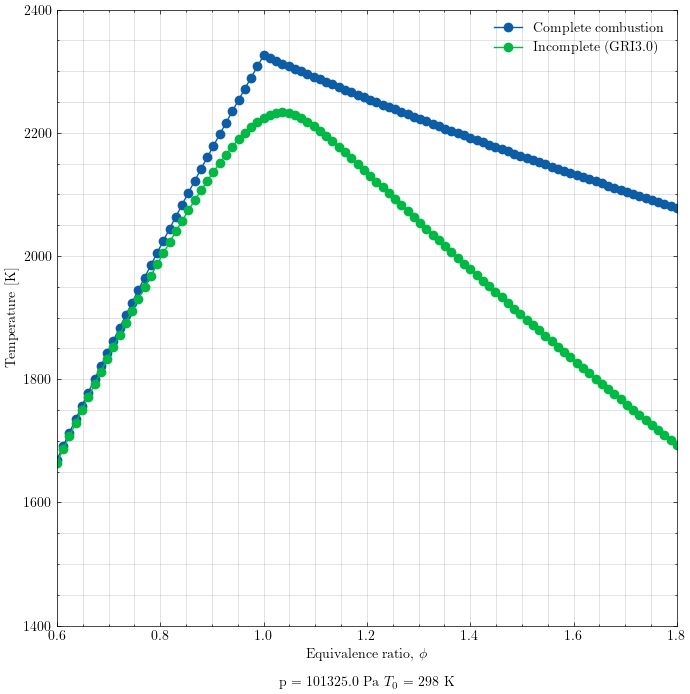

In [ ]:
plt.figure(figsize=(8,8))
# Tamaño de ventana

plt.plot(phi,
        T_ad_complete,
        label="Complete combustion",
        marker="o"
        )
plt.plot(phi,
        T_ad_incomplete,
        label="Incomplete (GRI3.0)",
        marker="o"
        )
    # phi es vector de abscisas y T_ad_incomplete, de ordenadas
    # lw: line width

ax = plt.gca()
# Ajuste Eje Y (Números cada 200, líneas cada 50)
ax.yaxis.set_major_locator(plt.MultipleLocator(200))
ax.yaxis.set_minor_locator(plt.MultipleLocator(50))
# Ajuste Eje X (Números cada 0.2, líneas cada 0.05)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.05))

plt.grid(True, which='both', alpha=0.5)

plt.xlabel("Equivalence ratio, "+ r"$\phi$"+ f"\n \n p = {p} Pa    $T_{{0}}$ = {T_0} K")
plt.ylabel("Temperature [K]")

plt.legend(loc='best', fontsize=10)
    # muestra las label definidas en plt.plot

plt.xlim(0.6,1.8)
plt.ylim(1400,2400)

plt.savefig("T_ad_vs_phi.svg")
plt.show()
    # muestra el gráfico
    # plt.show() debe ir después de plt.savefig()